## Simple MultiAI Agent Architecture

In [46]:
import os
from typing import TypedDict, Annotated, List, Literal
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, SystemMessage
from langchain_openai import ChatOpenAI
from langchain_core.tools import tool
from langchain_community.tools.tavily_search import TavilySearchResults
from langgraph.graph import StateGraph, END
from langgraph.prebuilt import create_react_agent
from langgraph.checkpoint.memory import MemorySaver

In [47]:
import os
from dotenv import load_dotenv
load_dotenv(dotenv_path=r"E:\Desktop\Data_Science\Gen_AI\Projects\.env")

os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")

In [48]:
from langgraph.graph import StateGraph, END, MessagesState
from langgraph.prebuilt import ToolNode
from langgraph.checkpoint.memory import MemorySaver

In [ ]:
## Define the state
class AgentState(MessagesState):
    next_agent:str #ehich agent should go next 

In [50]:
# Create simple tools
@tool
def search_web(query: str) -> str:
    """Search the web for information."""
    # Using Tavily for web search
    search = TavilySearchResults(max_results=3)
    results = search.invoke(query)
    return str(results)

@tool
def write_summary(content: str) -> str:
    """Write a summary of the provided content."""
    # Simple summary generation
    summary = f"Summary of findings:\n\n{content[:500]}..."
    return summary

In [51]:
from langchain.chat_models import init_chat_model

llm=init_chat_model("openai:gpt-4o-mini")
llm

ChatOpenAI(profile={'max_input_tokens': 128000, 'max_output_tokens': 16384, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'structured_output': True, 'image_url_inputs': True, 'pdf_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'tool_choice': True}, client=<openai.resources.chat.completions.completions.Completions object at 0x000001EDADF97E30>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x000001EDADF96A50>, root_client=<openai.OpenAI object at 0x000001EDADF960F0>, root_async_client=<openai.AsyncOpenAI object at 0x000001EDADF94AD0>, model_name='gpt-4o-mini', model_kwargs={}, openai_api_key=SecretStr('**********'), stream_usage=True)

In [52]:
# Define agent functions (simpler approach)
def researcher_agent(state: AgentState):
    """Researcher agent that searches for information"""
    
    messages = state["messages"]
    
    # Add system message for context
    system_msg = SystemMessage(content="You are a research assistant. Use the search_web tool to find information about the user's request.")
    
    # Call LLM with tools
    researcher_llm = llm.bind_tools([search_web])
    response = researcher_llm.invoke([system_msg] + messages)
    
    # Return the response and route to writer
    return {
        "messages": [response],
        "next_agent": "writer"
    }

In [53]:
def writer_agent(state: AgentState):
    """Writer agent that creates summaries"""
    
    messages = state["messages"]
    
    # Add system message
    system_msg = SystemMessage(content="You are a technical writer. Review the conversation and create a clear, concise summary of the findings.")
    
    # Simple completion without tools
    response = llm.invoke([system_msg] + messages)
    
    return {
        "messages": [response],
        "next_agent": "end"
    }

In [54]:
# Tool executor node
def execute_tools(state: AgentState):
    """Execute any pending tool calls"""
    messages = state["messages"]
    last_message = messages[-1]
    
    # Check if there are tool calls to execute
    if hasattr(last_message, "tool_calls") and last_message.tool_calls:
        # Create tool node and execute
        tool_node = ToolNode([search_web, write_summary])
        response = tool_node.invoke(state)
        return response
    
    # No tools to execute
    return state

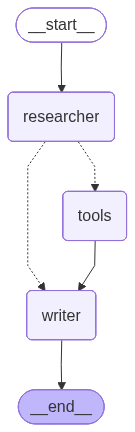

In [55]:
# Build graph
workflow = StateGraph(AgentState)

# Add nodes
workflow.add_node("researcher", researcher_agent)
workflow.add_node("tools", execute_tools)
workflow.add_node("writer", writer_agent)

# Conditional routing: if researcher made tool calls, execute them first
def route_after_researcher(state: AgentState):
    last_message = state["messages"][-1]
    if hasattr(last_message, "tool_calls") and last_message.tool_calls:
        return "tools"
    return "writer"

# Define flow
workflow.set_entry_point("researcher")
workflow.add_conditional_edges("researcher", route_after_researcher, {"tools": "tools", "writer": "writer"})
workflow.add_edge("tools", "writer")
workflow.add_edge("writer", END)
final_workflow = workflow.compile()

final_workflow


In [56]:
response=final_workflow.invoke({"messages":"Reasearch about the usecase of agentic ai in business"})

In [57]:
response["messages"][-1].content

'**Summary of Findings on Agentic AI Use Cases in Business**\n\nAgentic AI, characterized by its ability for purposeful and self-directed behavior, is increasingly being integrated into business processes across various sectors to enhance efficiency and decision-making. \n\n1. **Key Attributes**: \n   - Agentic AI systems can sense their environment, process information, and make decisions with minimal human intervention. \n   - These systems continuously learn from interactions, allowing businesses to transition from reactive to anticipatory approaches.\n\n2. **Use Cases in Industries**:\n   - **Financial Services**: Companies like JPMorgan Chase are employing AI to detect fraud, offer personalized financial advice, and automate compliance processes, potentially reducing reliance on junior staff.\n   - **Retail**: Walmart utilizes LLM-powered AI agents for automating personal shopping experiences and improving customer service and operational efficiency, including merchandise planning